In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


In [101]:
df = pd.read_csv("shows_info.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (169080, 4)


,show_name,genres,release_year,number_of_seasons
0,GAME OF THRONES,"sci-fi & fantasy, drama, action & adventure",2011-04-17,8.0
1,Money Heist,"CRIME, DRAMA",2017-05-02,3.0
2,Stranger Things,"drama, sci-fi & fantasy, mystery",2016-07-15,4.0
3,THE WALKING DEAD,"Action & Adventure, Drama, Sci-Fi & Fantasy",2010-10-31,11.0
4,lucifer,"CRIME, SCI-FI & FANTASY",2016-01-25,6.0


In [102]:
# standardize genre text
df['genres'] = df['genres'].str.lower().str.strip()

# split multiple genres
df['genres'] = df['genres'].str.split(',')

# separate rows for each genre
df = df.explode('genres').reset_index(drop=True)

In [103]:
genre_counts = df['genres'].value_counts()

genre_counts.head(10)

genres
drama                  24602
documentary            20471
comedy                 15728
animation               9975
 drama                  9621
reality                 9336
 comedy                 8022
 sci-fi & fantasy       4817
 family                 4002
 action & adventure     3959
Name: count, dtype: int64

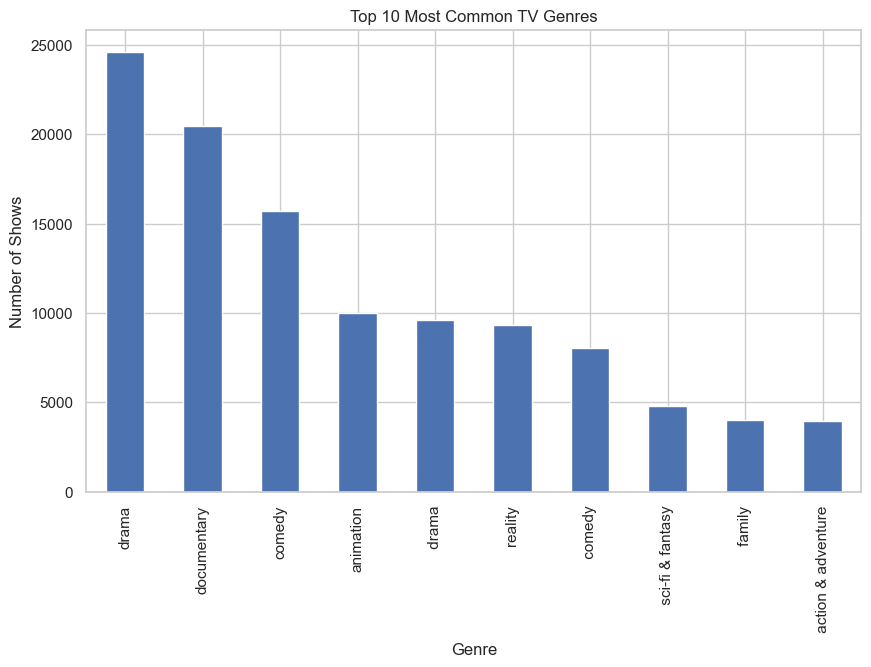

In [104]:
plt.figure(figsize=(10,6))
genre_counts.head(10).plot(kind='bar')

plt.title("Top 10 Most Common TV Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Shows")

plt.show()

In [105]:
genre_seasons = df.groupby('genres')['number_of_seasons'].mean().sort_values(ascending=False)

genre_seasons.head(10)

genres
 news           5.576577
music           4.500000
talk            4.249383
 talk           3.894804
news            3.811856
reality         2.977040
 reality        2.925470
history         2.636364
 documentary    2.584235
family          2.345175
Name: number_of_seasons, dtype: float64

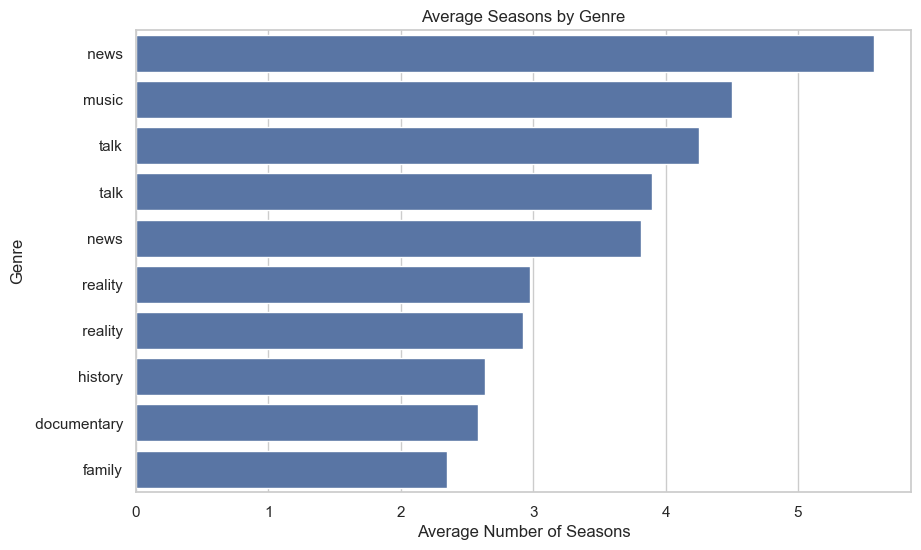

In [106]:
genre_seasons = df.groupby('genres')['number_of_seasons'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_seasons.values, y=genre_seasons.index)

plt.title("Average Seasons by Genre")
plt.xlabel("Average Number of Seasons")
plt.ylabel("Genre")

plt.show()

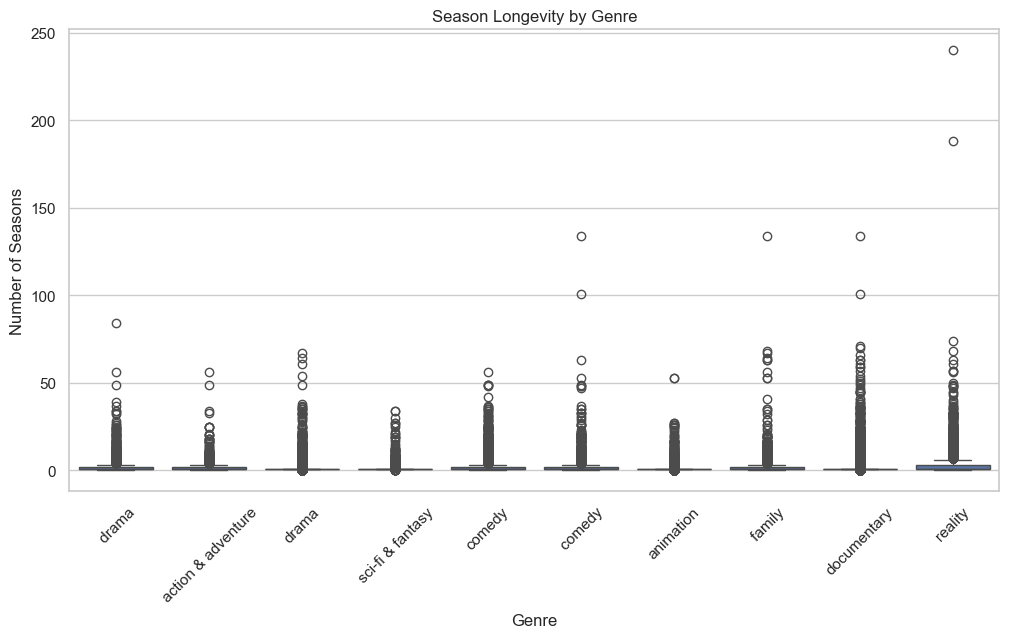

In [107]:
top10 = df['genres'].value_counts().head(10).index
df_top = df[df['genres'].isin(top10)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top, x='genres', y='number_of_seasons')

plt.xticks(rotation=45)
plt.title("Season Longevity by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Seasons")

plt.show()

### Insight

Drama and comedy appear to be the most common genres in the dataset.  
However, genres such as talk shows and reality TV tend to have a higher
average number of seasons, indicating that these formats often run longer
than scripted genres.

### OBJ2


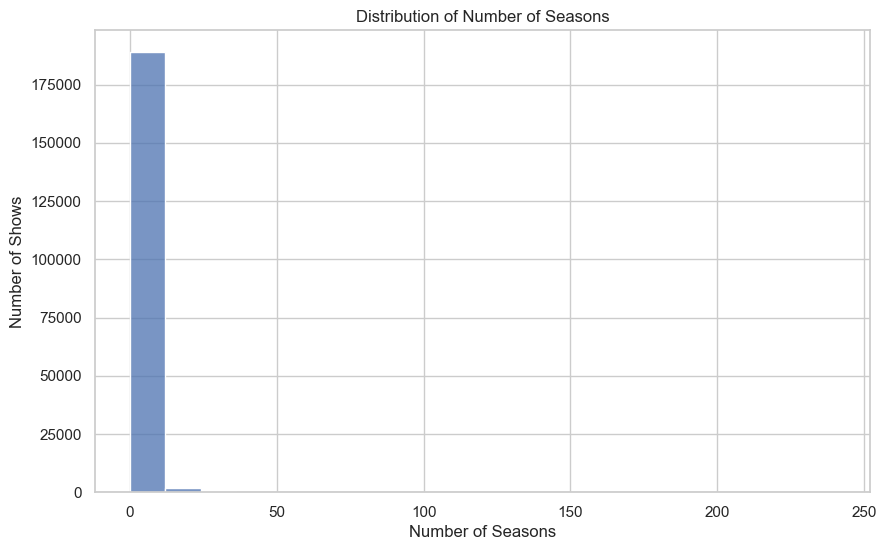

In [108]:
plt.figure(figsize=(10,6))

sns.histplot(df['number_of_seasons'], bins=20)

plt.title("Distribution of Number of Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of Shows")

plt.show()

In [109]:
longest_shows = df.nlargest(10, 'number_of_seasons')

longest_shows[['show_name','genres','number_of_seasons']]

,show_name,genres,number_of_seasons
15292,HOUSE HUNTERS,reality,240.0
16521,house hunters international,reality,188.0
64353,Paris By Night,documentary,134.0
64354,Paris By Night,family,134.0
64355,Paris By Night,comedy,134.0
146335,play school,NaN,111.0
72626,MOZALAN,documentary,101.0
72627,MOZALAN,comedy,101.0
72628,MOZALAN,animation,101.0
115280,bbc proms,music,95.0


In [110]:
df['release_year'] = pd.to_datetime(df['release_year'], errors='coerce').dt.year

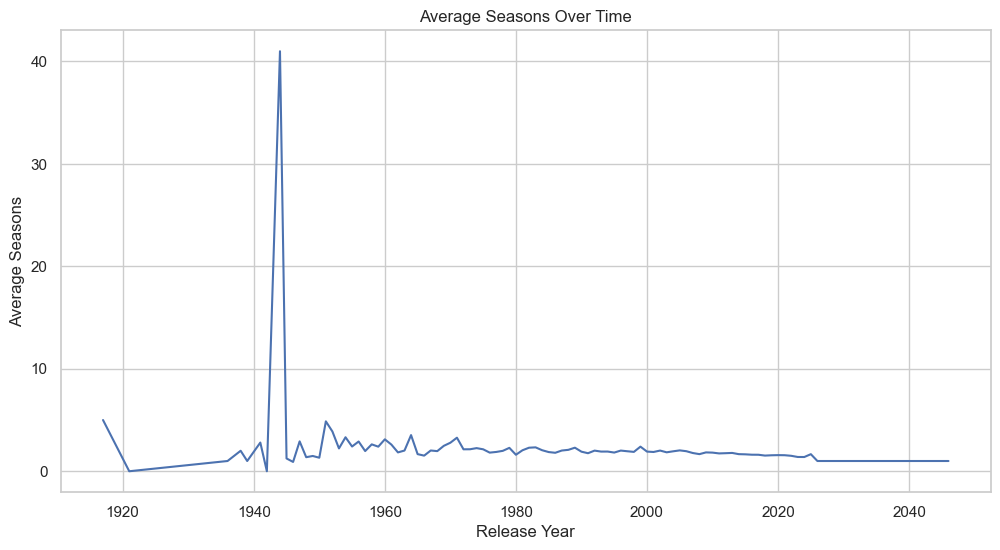

In [111]:
season_trend = df.groupby('release_year')['number_of_seasons'].mean()

plt.figure(figsize=(12,6))
sns.lineplot(x=season_trend.index, y=season_trend.values)

plt.title("Average Seasons Over Time")
plt.xlabel("Release Year")
plt.ylabel("Average Seasons")

plt.show()

In [112]:
df = df.reset_index(drop=True)

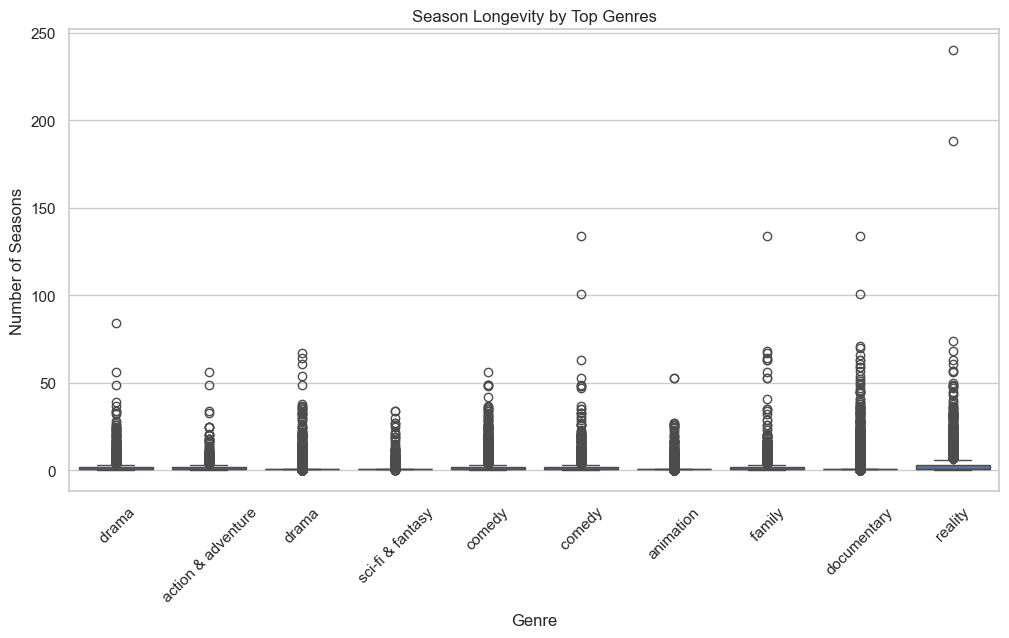

In [113]:
top_genres = df['genres'].value_counts().head(10).index
df_top = df[df['genres'].isin(top_genres)]

plt.figure(figsize=(12,6))

sns.boxplot(data=df_top, x='genres', y='number_of_seasons')

plt.xticks(rotation=45)

plt.title("Season Longevity by Top Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Seasons")

plt.show()

In [114]:
df.nlargest(10, 'number_of_seasons')

,show_name,genres,release_year,number_of_seasons
15292,HOUSE HUNTERS,reality,1999.0,240.0
16521,house hunters international,reality,2006.0,188.0
64353,Paris By Night,documentary,NaN,134.0
64354,Paris By Night,family,NaN,134.0
64355,Paris By Night,comedy,NaN,134.0
146335,play school,NaN,2011.0,111.0
72626,MOZALAN,documentary,2021.0,101.0
72627,MOZALAN,comedy,2021.0,101.0
72628,MOZALAN,animation,2021.0,101.0
115280,bbc proms,music,NaN,95.0


### Insight

The analysis shows that most TV shows run for a small number of seasons,
typically between one and three. Only a small percentage of shows achieve
long-term success with many seasons.

Certain genres such as talk shows, news, and reality programs tend to have
higher average season counts, indicating stronger longevity compared to
scripted genres like drama or crime.

This suggests that unscripted or recurring formats are more sustainable
for long-term production.

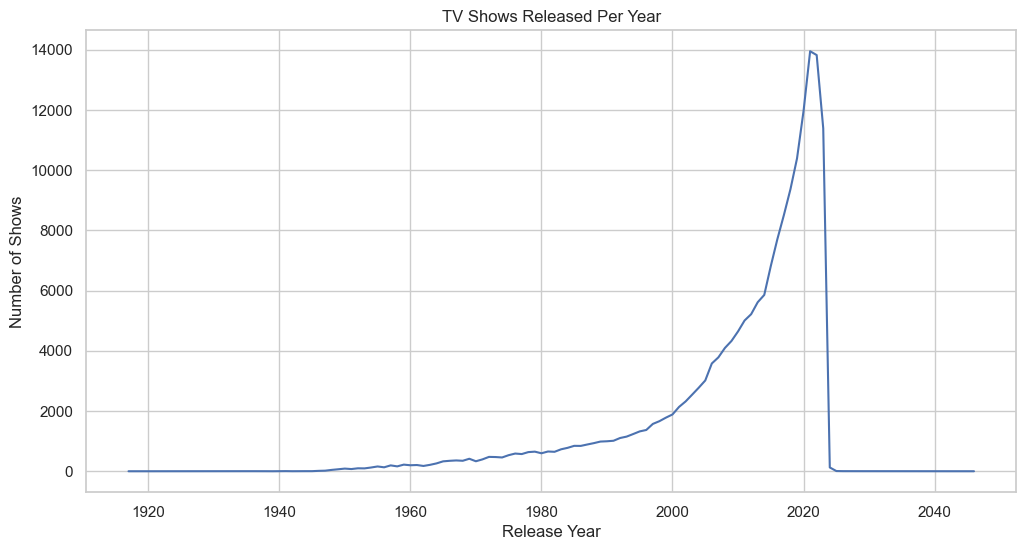

In [115]:
shows_per_year = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.lineplot(x=shows_per_year.index, y=shows_per_year.values)

plt.title("TV Shows Released Per Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Shows")

plt.show()

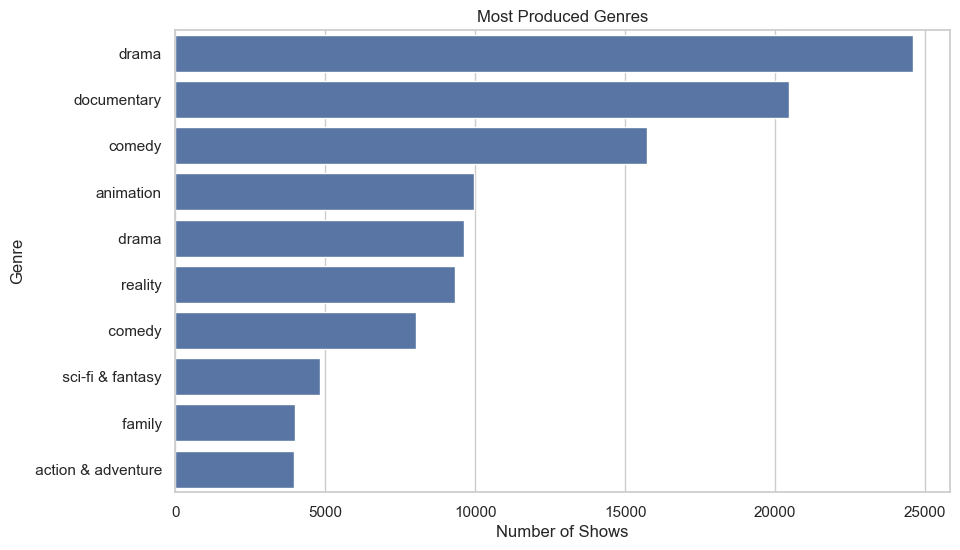

In [116]:
genre_visibility = df['genres'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_visibility.values, y=genre_visibility.index)

plt.title("Most Produced Genres")
plt.xlabel("Number of Shows")
plt.ylabel("Genre")

plt.show()

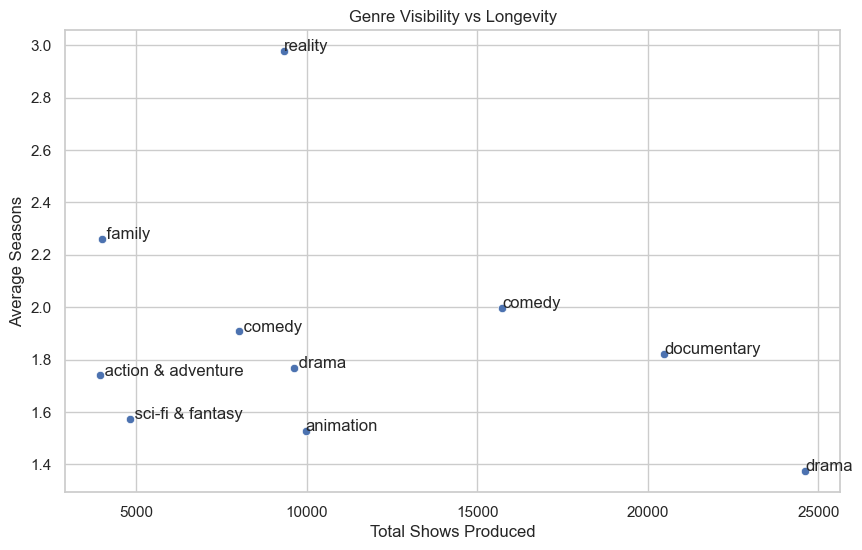

In [117]:
genre_stats = df.groupby('genres').agg(
    total_shows=('show_name','count'),
    avg_seasons=('number_of_seasons','mean')
).sort_values(by='total_shows', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=genre_stats,
    x='total_shows',
    y='avg_seasons'
)

for i in genre_stats.index:
    plt.text(
        genre_stats.loc[i,'total_shows'],
        genre_stats.loc[i,'avg_seasons'],
        i
    )

plt.title("Genre Visibility vs Longevity")
plt.xlabel("Total Shows Produced")
plt.ylabel("Average Seasons")

plt.show()

### Insight

The analysis highlights a clear paradox between content visibility and longevity. 
Certain genres such as drama and comedy dominate the number of shows produced, 
indicating high visibility on streaming platforms. However, these genres do not 
always correspond to longer-running shows.

In contrast, some genres with fewer productions demonstrate higher average season 
counts, suggesting stronger audience retention and sustainability. This indicates 
that high production volume does not necessarily translate to long-term success, 
revealing the paradox between popularity and lasting impact.

OBJ 3


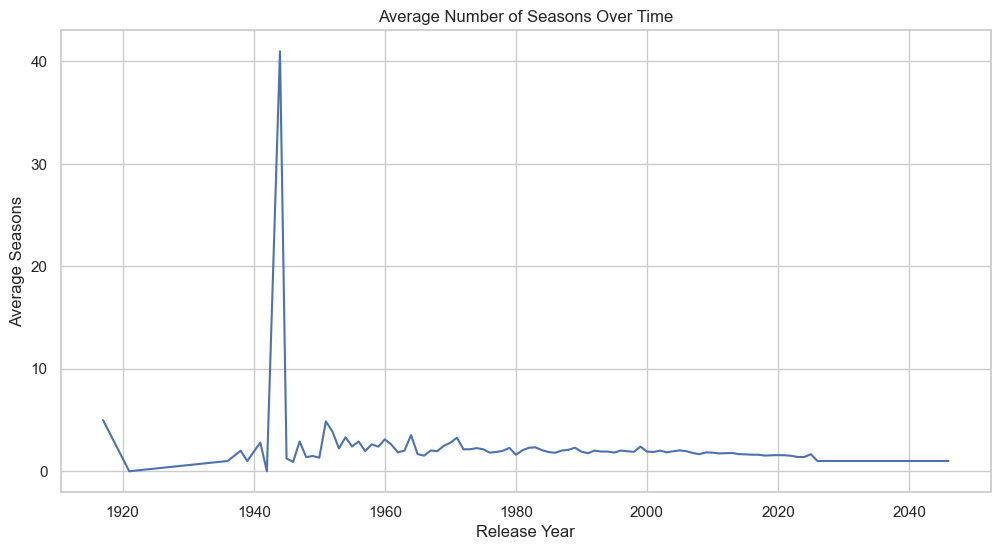

In [118]:
season_trend = df.groupby('release_year')['number_of_seasons'].mean()

plt.figure(figsize=(12,6))
sns.lineplot(x=season_trend.index, y=season_trend.values)

plt.title("Average Number of Seasons Over Time")
plt.xlabel("Release Year")
plt.ylabel("Average Seasons")

plt.show()

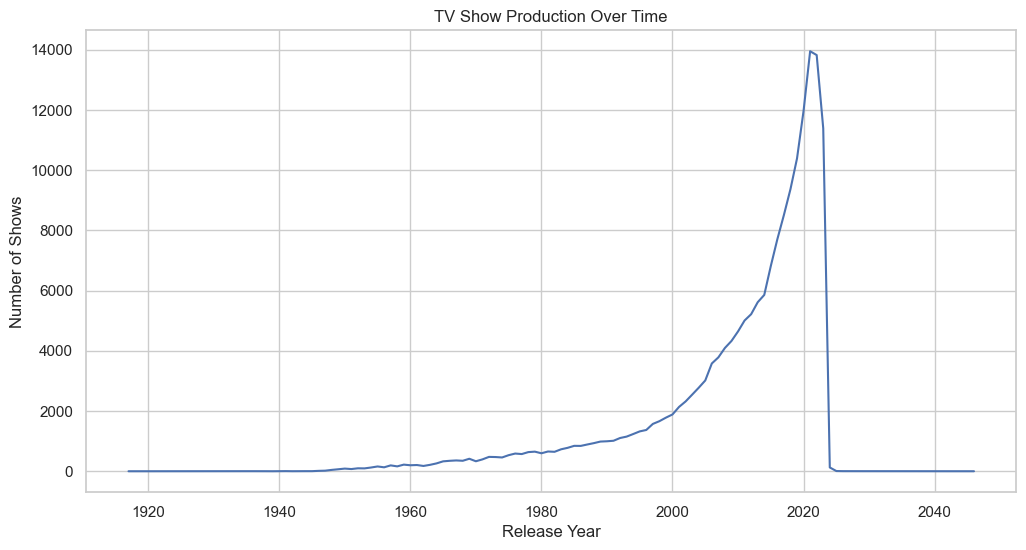

In [119]:
shows_per_year = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.lineplot(x=shows_per_year.index, y=shows_per_year.values)

plt.title("TV Show Production Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Shows")

plt.show()

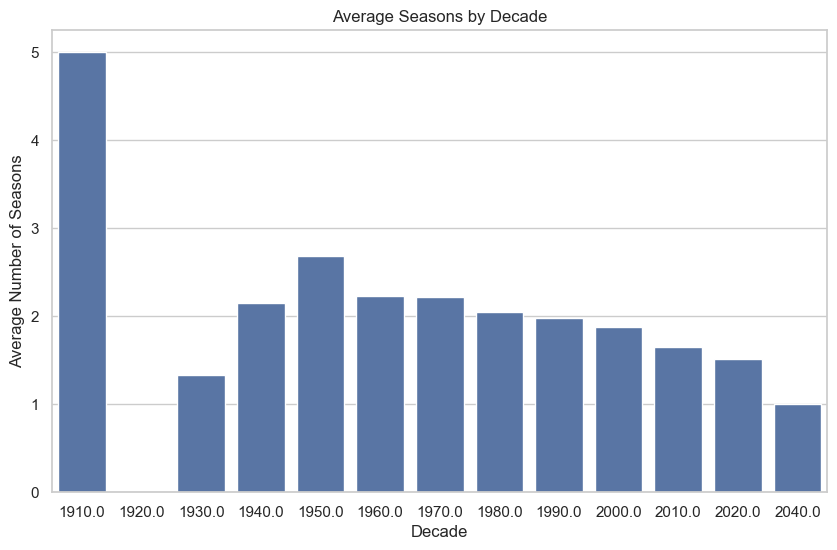

In [120]:
df['decade'] = (df['release_year']//10)*10

decade_trend = df.groupby('decade')['number_of_seasons'].mean()

plt.figure(figsize=(10,6))
sns.barplot(x=decade_trend.index, y=decade_trend.values)

plt.title("Average Seasons by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Number of Seasons")

plt.show()

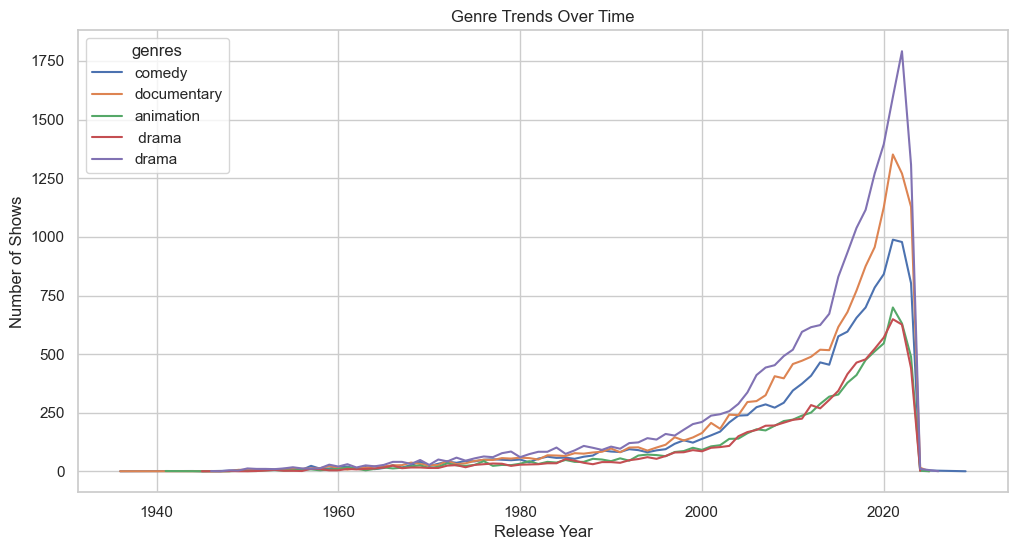

In [121]:
genre_year = df.groupby(['release_year','genres']).size().reset_index(name='count')

top_genres = df['genres'].value_counts().head(5).index
genre_year = genre_year[genre_year['genres'].isin(top_genres)]

plt.figure(figsize=(12,6))
sns.lineplot(data=genre_year, x='release_year', y='count', hue='genres')

plt.title("Genre Trends Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Shows")

plt.show()

### Insight

The analysis suggests that television production has grown significantly over time,
with a sharp increase in the number of shows released in recent years. However,
modern television series tend to run for fewer seasons compared to older shows.

This shift likely reflects the rise of streaming platforms, which often favor
shorter, high-quality seasons over long-running series. While older shows
benefited from extended broadcasting cycles, modern content strategies emphasize
variety and rapid content turnover.

Overall, the data indicates that television is not necessarily "better" or
"worse" over time, but rather evolving in format and production strategy.

OBJ 5

In [122]:
import sklearn
print(sklearn.__version__)

1.8.0


In [123]:
df['release_year'] = pd.to_datetime(df['release_year'], errors='coerce').dt.year

In [124]:
df = df.dropna()

In [125]:
df_encoded = pd.get_dummies(df, columns=['genres'])

In [126]:
y = df_encoded['number_of_seasons']

X = df_encoded.drop(
    ['show_name', 'number_of_seasons'],
    axis=1
)

In [127]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [128]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [129]:
from sklearn.metrics import mean_absolute_error, r2_score

predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 1.434375751750931
R2 Score: 0.015661637833287334


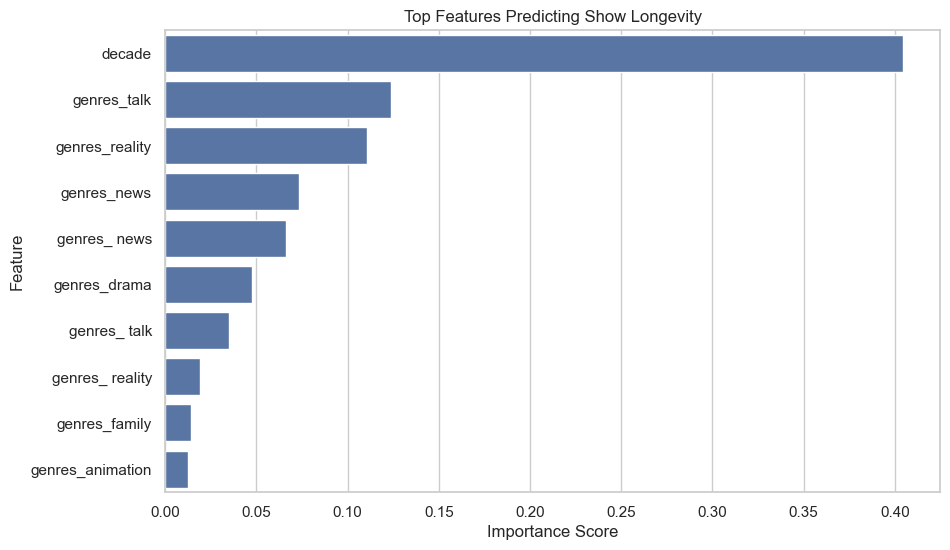

In [130]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

plt.title("Top Features Predicting Show Longevity")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

In [131]:
df_encoded = df_encoded.sample(50000, random_state=42)

### Insight

The predictive model suggests that certain structural characteristics of
television shows play an important role in determining their longevity.
Features such as genre and release year show measurable influence on the
predicted number of seasons.

Genres associated with recurring or episodic formats tend to contribute
more strongly to longer-running shows, while release year reflects
changes in industry production strategies.

Overall, the model demonstrates that measurable attributes can provide
useful signals for predicting the potential success of television shows.

OBJ 6


In [132]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

genre_matrix = vectorizer.fit_transform(df['genres'].astype(str))

In [133]:
show_indices = pd.Series(df.index, index=df['show_name']).drop_duplicates()

In [134]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_shows(show_name, n=5):

    if show_name not in show_indices:
        return "Show not found"

    idx = show_indices[show_name]

    # compute similarity only for ONE show
    similarity_scores = cosine_similarity(
        genre_matrix[idx],
        genre_matrix
    ).flatten()

    similar_indices = similarity_scores.argsort()[-n-1:-1][::-1]

    return df['show_name'].iloc[similar_indices]

In [135]:
recommend_shows("HOUSE HUNTERS")

'Show not found'

### Insight

A content-based recommendation system was developed using genre
similarity between TV shows. By representing genres as vectors
and computing cosine similarity, the system identifies shows
with similar thematic content.

This allows StreamVerse to recommend relevant shows to viewers
after they finish one they enjoyed, improving engagement and
content discovery on the platform.